In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.data_loader import load_prices

In [2]:
tickers = ["SPY", "QQQ", "GLD", "TLT", "MSFT"]
df = load_prices(tickers, "2020-01-01", "2024-12-31", save=False)
df_normalized=100*df/df.iloc[0]

[*********************100%***********************]  5 of 5 completed


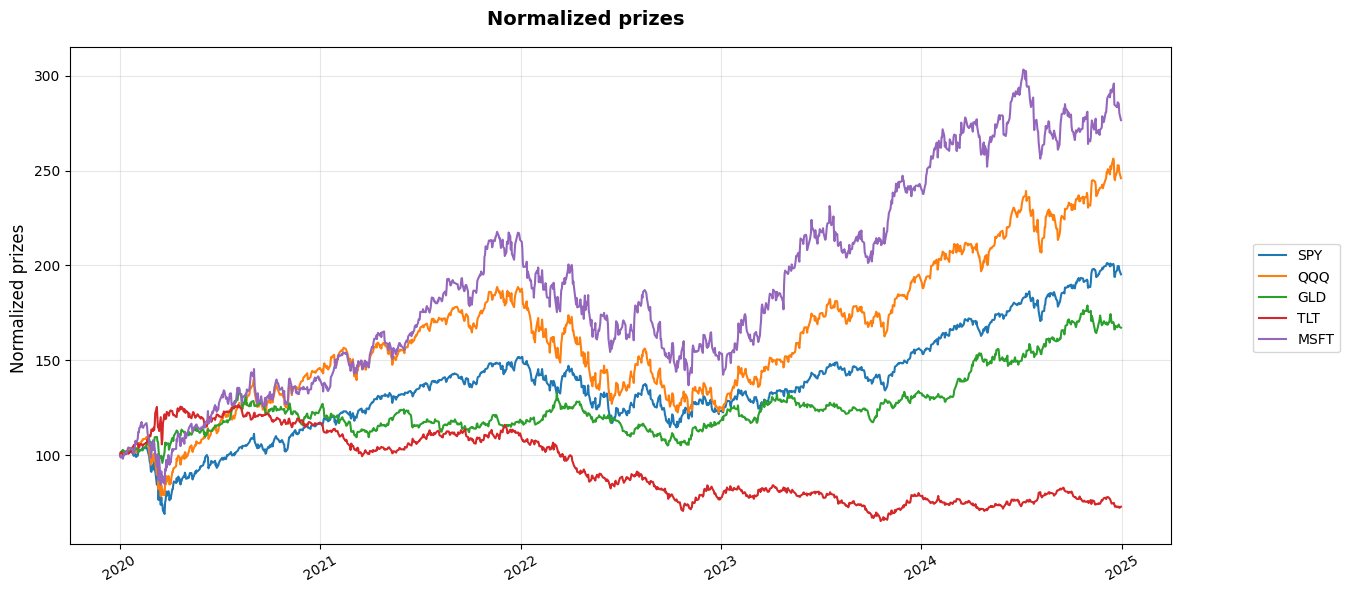

In [ ]:
fig, ax=plt.subplots(figsize=(12, 6))
fig.suptitle("Normalized prizes", fontsize=14, fontweight="bold")

for ticker in tickers:
    ax.plot(df_normalized.index, df_normalized[ticker], label=ticker)

handles, labels=ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc="center left")
fig.supylabel("Normalized prizes")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

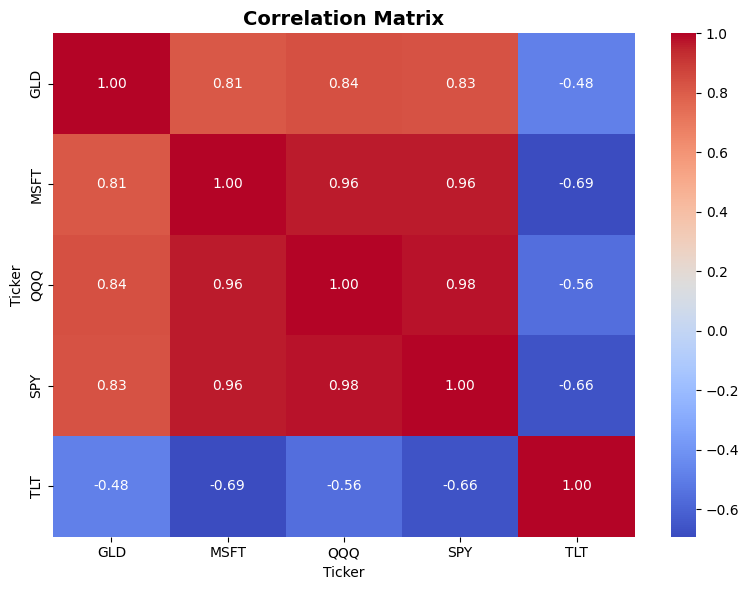

In [4]:
corr=df.corr()
fig, ax=plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

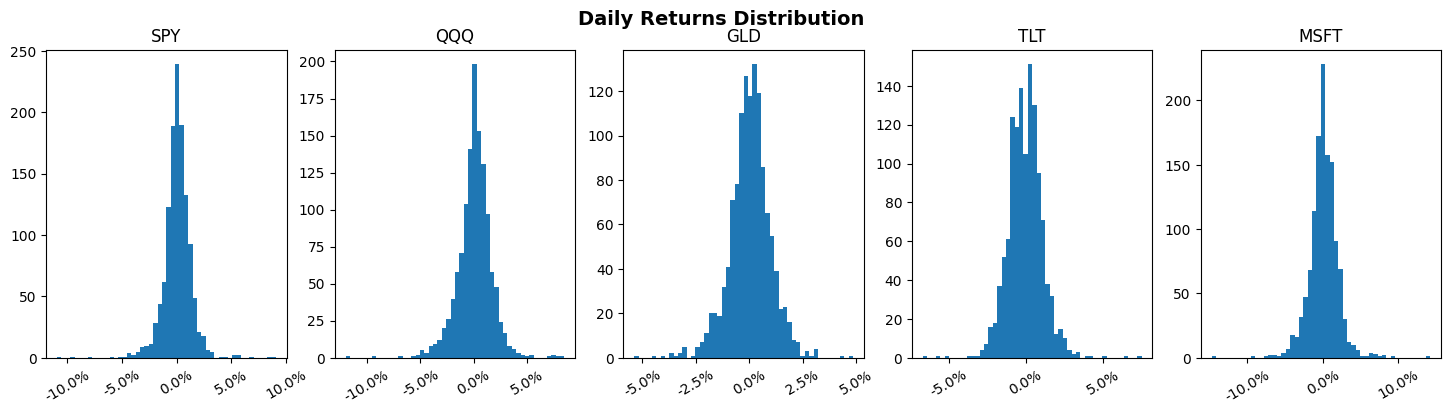

In [22]:
returns=df.pct_change()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle("Daily Returns Distribution", fontsize=14, fontweight="bold")

for ticker, ax in zip(tickers, axes):
    ax.hist(returns[ticker].dropna(), bins=50)
    ax.set_title(ticker)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
    ax.tick_params(axis="x", rotation=30)

plt.show()

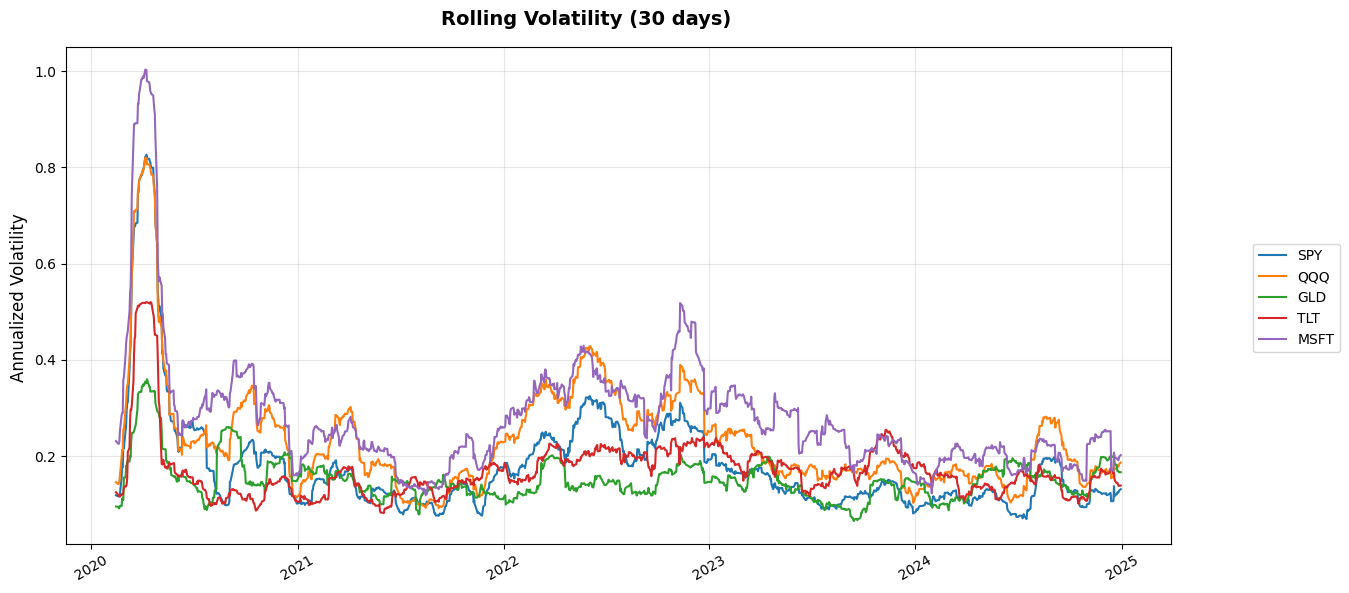

In [23]:
rolling_vol=returns.rolling(30).std()*(255**0.5)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle("Rolling Volatility (30 days)", fontsize=14, fontweight="bold")

for ticker in tickers:
    ax.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc="center left")
fig.supylabel("Annualized Volatility")
ax.tick_params(axis="x", rotation=30)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()